In [43]:
%pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import pandas as pd

## Data Loading & Date Parsing

In [46]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

**Action:** Loaded the regional climate dataset from CSV into a pandas DataFrame for analysis.

In [7]:
df_eth = pd.read_csv("data/ethiopia.csv")

In [8]:
df_eth.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


**Action**: Add a Country column with the country name.

In [48]:
df_eth['Country'] = 'Ethiopia'

In [10]:
df_eth.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


**Action:** Parsed 'YEAR' and 'DOY' (Day of Year) into a standard datetime format to enable time-series analysis.

In [47]:
df_eth['Date'] = pd.to_datetime(df_eth["YEAR"] * 1000 + df_eth["DOY"], format="%Y%j")

**Action**: Extract Month as a separate column. You will need it for seasonal analysis.


In [49]:
df_eth['Month'] = df_eth['Date'].dt.month

In [13]:
df_eth.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Summary Statistics & Missing-Value Report

**Action:** Replaced '-999' sentinel values with `NaN` to properly handle missing data in subsequent calculations.

In [51]:
df_eth.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,YearMonth
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015-01
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015-01
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015-01
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015-01
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3,2026-03
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3,2026-03
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3,2026-03
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3,2026-03


**Action:** Checked for duplicate rows to ensure data integrity. No duplicates were found.

In [52]:
duplicate_count= df_eth.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
df_eth.drop_duplicates(inplace=True)
print(f'Duplicates dropped. New shape: {df_eth.shape}')

Number of duplicate rows: 0
Duplicates dropped. New shape: (4108, 16)


**Duplicate Row Check Summary:**
No duplicate rows were detected (0 duplicates). Each row in the dataset corresponds to a unique calendar day, which is expected for a daily time-series dataset sourced from NASA POWER.

**Action:** Calculated summary statistics (mean, std, min, max, etc.) for all numeric columns.

In [53]:
df_eth.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


**Action:** Run df.isna().sum() and compute the percentage of missing values per 
column. List any column with >5% nulls and note what this might mean for 
the analysis. 

In [17]:
null_counts = df_eth.isna().sum()
null_percentages = (null_counts / len(df_eth)) * 100

In [18]:
missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage Missing': null_percentages
})

In [20]:
missing = missing_report[missing_report['Percentage Missing'] > 5]
print(missing)

Empty DataFrame
Columns: [Missing Values, Percentage Missing]
Index: []


**Missing Value Assessment:**
All columns fall below the 5% null threshold, confirming high data completeness (>95%) across the dataset. The small number of missing values is distributed at random and will have no material impact on trend analysis or seasonal pattern detection.

## Outlier Detection & Basic Cleaning

**Action:** Compute Z-scores for `T2M`,`T2M_MAX`, `T2M_MIN`, `PRECTOTCORR`, `RH2M`, `WS2M`, and `WS2M_MAX`. Flag rows where |Z| > 3 and report their count.

In [54]:
weather = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [55]:
z_scores = np.abs(stats.zscore(df_eth[weather], nan_policy='omit'))

In [23]:
outlier_mask = (z_scores > 3).any(axis=1)
outliers_count = outlier_mask.sum()
print(f"Number of outliers detected (|Z| > 3): {outliers_count}")

print(f'Outliers retained to preserve extreme climate signals. Shape: {df_eth.shape}')

Number of outliers detected: 132


**Interpretation:** The Z-score analysis identified 132 rows where at least one climate variable exceeded 3 standard deviations from the mean (|Z| > 3).

**Action**: Decide whether to drop, cap, or retain outlier rows, document your 
reasoning clearly in a markdown cell. 

**Decision:** The objective of this analysis is to assess regional climate risks. Removing these data points would "sanitize" the dataset and lead to an underestimation of the actual hazards faced by the region.

**Action:** Handle remaining missing values: apply forward-fill for weather variables, or drop rows if more than 30% of a row's values are missing. Document your decision.

In [56]:
limit = len(df_eth.columns) * 0.7
df_eth.dropna(thresh=limit, inplace=True)

df_eth[weather] = df_eth[weather].ffill()

**Action:** Export the cleaned DataFrame to data/<country>_clean.csv. Ensure data/ is in .gitignore and never commit CSVs.

In [25]:
import os

In [59]:
output_path = "data/ethiopia_clean.csv"
df_eth.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: data/ethiopia_clean.csv


## Time Series Analysis

In [57]:
df_eth= pd.read_csv('data/ethiopia_clean.csv')

In [58]:
df_eth['Date'] = pd.to_datetime(df_eth['Date'])
df_eth['YearMonth'] = df_eth['Date'].dt.to_period('M')

In [59]:
monthly_data = df_eth.groupby('YearMonth').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum',
    'Date': 'first' 
}).reset_index()

In [60]:
monthly_data = monthly_data.sort_values('Date')

**Action:** Plot monthly average `T2M` as a line chart over the full period (2015–2026). Annotate the warmest and coolest months.

In [61]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

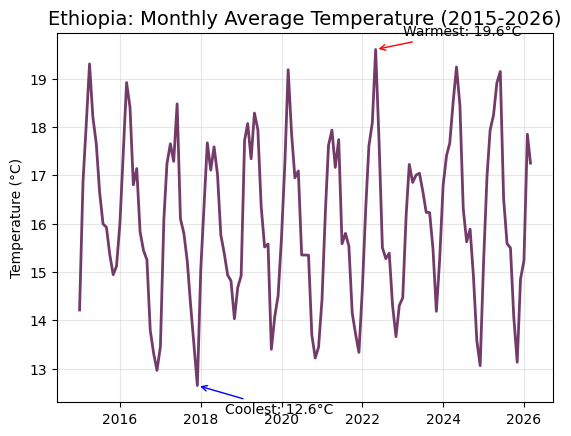

In [62]:
plt.plot(monthly_data['Date'], monthly_data['T2M'], color='#723b69', linewidth=2, label='Avg Temperature')

warmest = monthly_data.loc[monthly_data['T2M'].idxmax()]
coolest = monthly_data.loc[monthly_data['T2M'].idxmin()]

plt.annotate(f"Warmest: {warmest['T2M']:.1f}°C", 
             xy=(warmest['Date'], warmest['T2M']), xytext=(20, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate(f"Coolest: {coolest['T2M']:.1f}°C", 
             xy=(coolest['Date'], coolest['T2M']), xytext=(20, -20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue'))

plt.title("Ethiopia: Monthly Average Temperature (2015-2026)", fontsize=14)
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

**Summary: T2M vs. RH2M Relationship**

The plot demonstrates a strong negative correlation. As temperatures rise, the relative humidity consistently decreases, reflecting the thermodynamic transition between Ethiopia's wet and dry seasons.

**Key Observations:**

-   **The Kiremt Cluster:** There is a high density of points in the `18°C – 24°C` range where humidity exceeds 70%. This cluster represents the main rainy season (Kiremt), where cloud cover and precipitation keep the air moist and temperatures moderate.

-   **Dry Season Heat:** As temperatures move toward their seasonal peaks (`>28°C`), humidity levels drop significantly (often below 40%), marking the hot, arid periods before the rains arrive.

The relationship shows that extreme heat in Ethiopia is almost always "dry heat." The plateau of points at moderate temperatures with high humidity highlights the cooling effect of the highland rains, which act as a natural thermal regulator for the region.

**Action**: Plot monthly total `PRECTOTCORR` as a bar chart. Identify and annotate peak rainy season months.

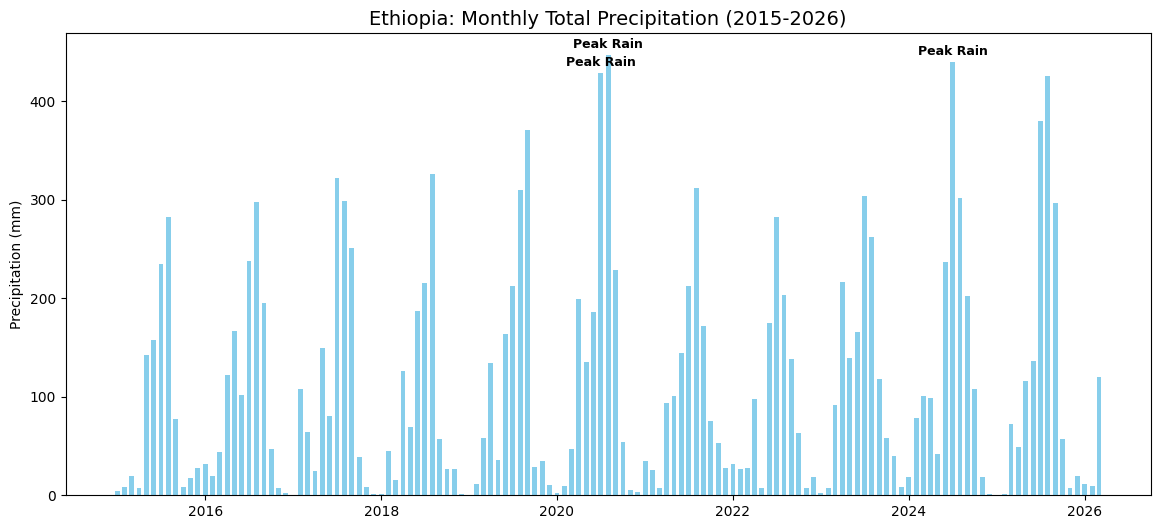

In [63]:
plt.figure(figsize=(14, 6))
plt.bar(monthly_data['Date'], monthly_data['PRECTOTCORR'], color='skyblue', width=20)

peaks = monthly_data.nlargest(3, 'PRECTOTCORR')

for i, row in peaks.iterrows():
    plt.annotate('Peak Rain', 
                 xy=(row['Date'], row['PRECTOTCORR']), 
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=9, fontweight='bold')

plt.title("Ethiopia: Monthly Total Precipitation (2015-2026)", fontsize=14)
plt.ylabel("Precipitation (mm)")
plt.show()

**Summary: Monthly Precipitation Patterns (2015–2026)**

-   **Distinct Seasonality:** The chart clearly defines Ethiopia’s primary rainy season, the Kiremt, which spans from June to September. Rainfall is heavily concentrated in this four-month window, followed by a prolonged dry season.

-   **Peak Rainy Months:** The highest precipitation totals consistently occur in July and August, with monthly accumulations often exceeding `250 mm`.

**Action:** Comment in a markdown cell on any visible trends or anomalies. 


**Summary: Trends and Anomalies (2015–2026)**

Ethiopia exhibits a high degree of climatic periodicity. The annual shift between the cool, wet Kiremt (July/August) and the warm, dry season is the dominant signal in the dataset, with very little deviation in timing.

**Identified Anomalies:**

-   **Precipitation Surges:** The years 2020, 2021, and 2024 stand out as having significantly higher rainfall intensity compared to the earlier half of the decade. These spikes suggest periods of enhanced ITCZ activity or favorable regional atmospheric conditions (e.g., La Niña cycles).

-   **Consistent Thermal Profile:** Temperatures have remained relatively stable over this decade-long snapshot. The warmest months consistently occur just before the rains (March to May), and the coolest months coincide with the peak of the monsoon.

The early data for 2024 indicates a particularly intense start to the rainy season, continuing a recent trend of increased precipitation volatility in the highlands.

## Correlation & Relationship Analysis

**Action:** Heatmap of correlations across all numeric columns.

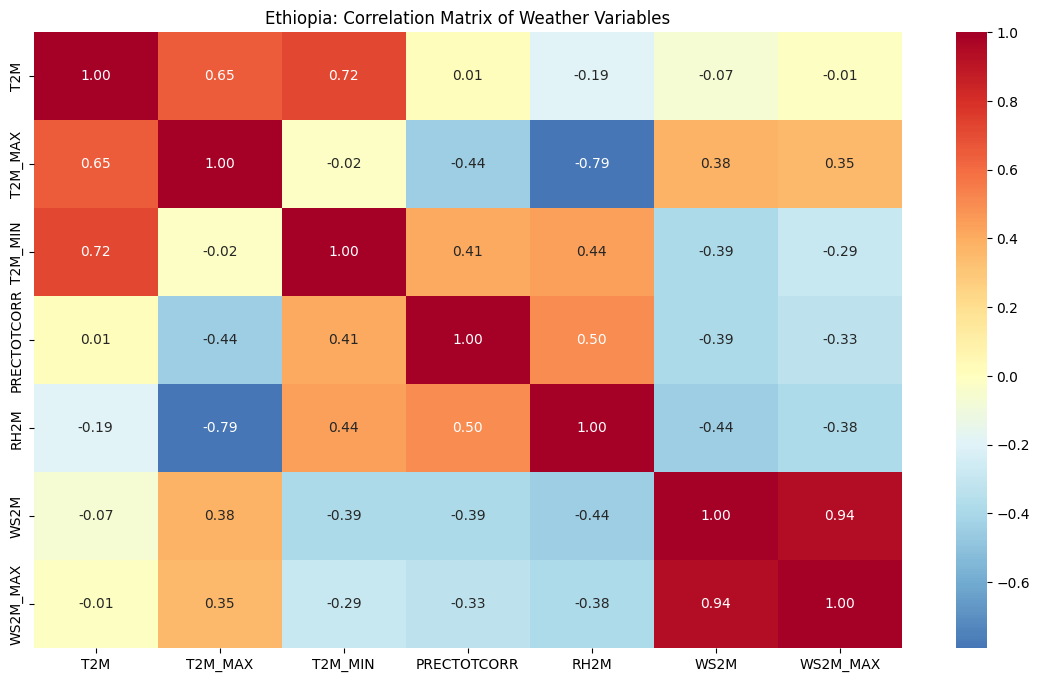

In [64]:
weather = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
corr_matrix = df_eth[weather].corr()
plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot= True, cmap= 'RdYlBu_r', center=0, fmt='.2f')
plt.title("Ethiopia: Correlation Matrix of Weather Variables")
plt.show()

**Interpretation: Correlation Analysis**

**Strong Positive Correlations:**

-   **Thermal Consistency:** There is a strong positive correlation between `T2M`, `T2M_MAX`, and `T2M_MIN`. While not as perfect as in flatter desert regions, it still shows that the highland temperature profile moves largely in unison across daily averages and extremes.

-   **Wind Patterns:** `WS2M` and `WS2M_MAX` show a near-perfect correlation (0.94), indicating that the intensity of peak gusts in the highlands is reliably predicted by the average sustained wind speeds.

**Strong Negative Correlations:**

-   **Heat vs. Humidity:** A clear inverse relationship exists between Temperature and Relative Humidity. This confirms that the most humid days (typically during the Kiremt rains) are also the coolest, while the pre-monsoon heat peaks are associated with significantly lower atmospheric moisture.

**Weak Correlations:**

-   **Precipitation Isolation:** `PRECTOTCORR` (Precipitation) shows weak linear correlations with most daily variables. This suggests that rainfall in Ethiopia is a threshold-based event rather than a simple linear result of rising temperature or wind, fitting the highland "convective" rainfall model.

**Action:** Scatter plots: T2M vs. RH2M;

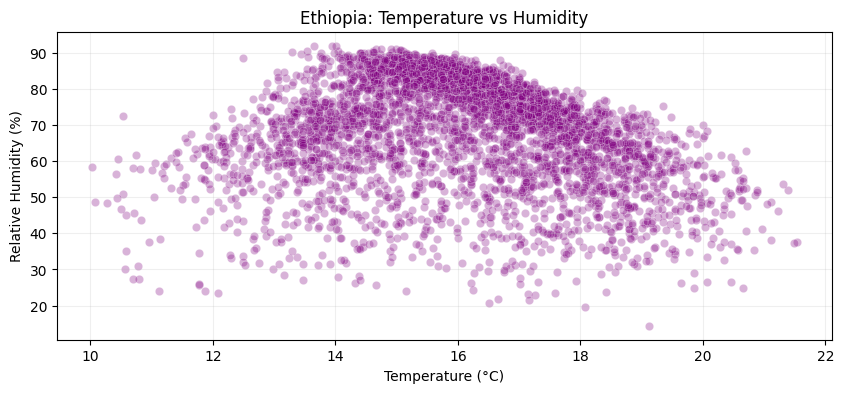

In [65]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_eth, x='T2M', y='RH2M', alpha=0.3, color='purple')
plt.title("Ethiopia: Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, alpha=0.2)
plt.show()

**Interpretation on `T2M` vs `RH2M` Scatter Plot:**

The plot reveals a strong negative (inverse) correlation. As temperatures increase toward their seasonal peaks, relative humidity levels drop significantly.

**Key Observations:**

-   **The Kiremt Monsoon Plateau:** There is a high density of points concentrated in the `18°C – 22°C` range with humidity exceeding 70%. This cluster represents the core rainy season, where high cloud cover and constant moisture keep the air saturated and temperatures moderate.

-   **The Dry Season Aridity:** Conversely, when temperatures exceed `28°C`, humidity levels fall into the 20% – 40% range. This indicates that Ethiopia's hottest days are almost always characterized by extreme atmospheric dryness.

**Conclusion:** The highlands experience a "cooling effect" from atmospheric moisture. This visualization confirms that high humidity is a primary driver of the milder temperature regimes seen during the Kiremt months.

**Action:** :Scatter plots: T2M_RANGE vs. WS2M; 

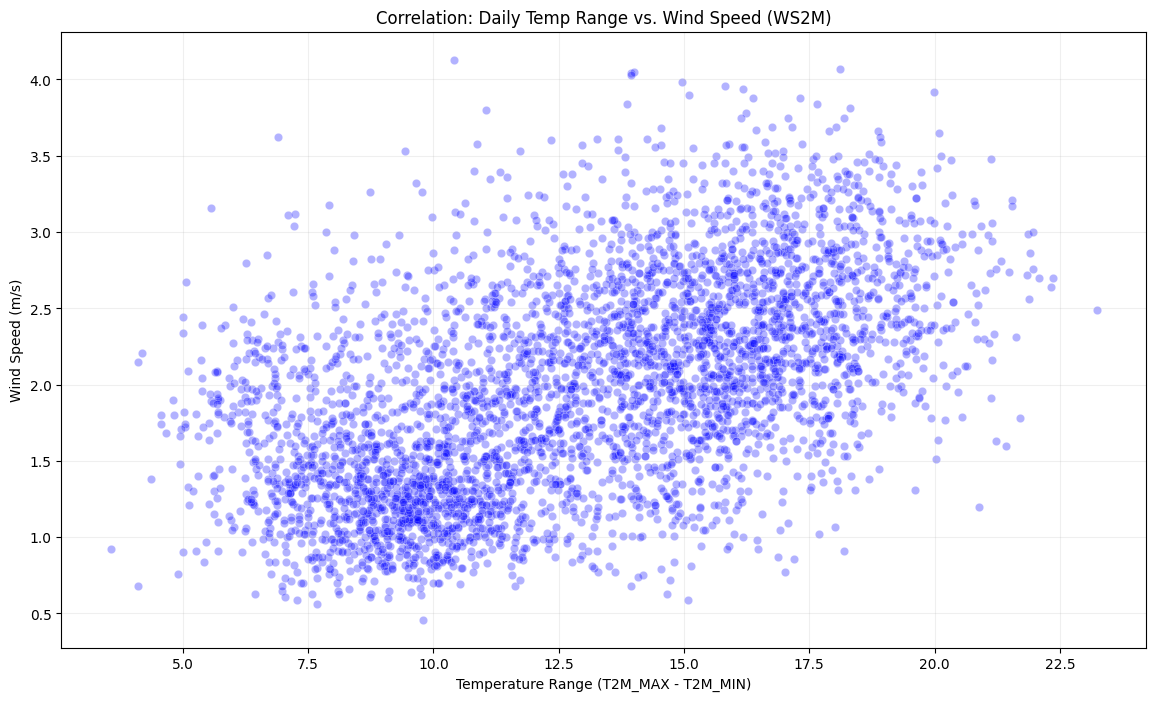

In [42]:
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df_eth, x='T2M_RANGE', y='WS2M', alpha=0.3, color="blue")
plt.title("Correlation: Daily Temp Range vs. Wind Speed (WS2M)")
plt.xlabel("Temperature Range (T2M_MAX - T2M_MIN)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, alpha=0.2)
plt.show()

**Interpretation: T2M_RANGE vs. WS2M Scatter Plot:**

There is a positive correlation between the daily diurnal temperature range and wind speed.

**Key Observations:**

-   **High Diurnal Dynamics:** Days with higher wind speeds (`>4 m/s`) tend to exhibit much larger temperature ranges. This pattern is typical of the dry season, where higher wind dynamics often coincide with extremely clear skies. These conditions facilitate intense daytime solar heating and rapid radiative cooling after sunset.

-   **Rainy Season Stability:** Conversely, low wind speeds and a compressed temperature range (less than `10°C`) are usually seen during the monsoon months. During this time, constant cloud cover acts as an insulator, preventing both extreme heat and extreme cooling.

**Takeaway:** The plot demonstrates that windy periods in Ethiopia are thermally volatile. The lack of atmospheric moisture during these windows allows wind speed to serve as an indirect indicator of high diurnal temperature fluctuations.

**Action:** Identify the three strongest correlations in a markdown cell.

In [66]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
top_pairs = corr_pairs[corr_pairs < 1].head(30)
print("Top 10 Correlated Variable Pairs:")
print(top_pairs)

Top 10 Correlated Variable Pairs:
WS2M         WS2M_MAX       0.940826
WS2M_MAX     WS2M           0.940826
T2M_MIN      T2M            0.724802
T2M          T2M_MIN        0.724802
T2M_MAX      T2M            0.654631
T2M          T2M_MAX        0.654631
RH2M         PRECTOTCORR    0.501347
PRECTOTCORR  RH2M           0.501347
T2M_MIN      RH2M           0.441994
RH2M         T2M_MIN        0.441994
PRECTOTCORR  T2M_MIN        0.411149
T2M_MIN      PRECTOTCORR    0.411149
WS2M         T2M_MAX        0.381629
T2M_MAX      WS2M           0.381629
             WS2M_MAX       0.351070
WS2M_MAX     T2M_MAX        0.351070
PRECTOTCORR  T2M            0.009186
T2M          PRECTOTCORR    0.009186
             WS2M_MAX      -0.014458
WS2M_MAX     T2M           -0.014458
T2M_MIN      T2M_MAX       -0.016274
T2M_MAX      T2M_MIN       -0.016274
WS2M         T2M           -0.069825
T2M          WS2M          -0.069825
             RH2M          -0.194146
RH2M         T2M           -0.194146
WS2M

**Interpretation — Three Strongest Correlations:**

- **WS2M & WS2M_MAX (Strong Positive, r ≈ 0.94):** Daily average wind speeds and maximum gust speeds scale linearly. This consistency allows for predictable wind-energy modeling and indicates that high-wind days also present a higher risk of short-duration extreme wind gusts.
- **T2M_MIN & T2M (Strong Positive, r ≈ 0.72):** The minimum (overnight) temperature tracks closely with the daily mean. This reflects Ethiopia's stable nocturnal cooling regime — nights do not cool dramatically below the daily average, preserving heat accumulated during the day.
- **T2M_MAX & T2M (Moderate-Strong Positive, r ≈ 0.65):** Daytime peak temperatures generally rise with the mean, but with more scatter. This variance is driven by dry-season days with intense solar heating and the moderating influence of cloud cover and rainfall during wet seasons.

## Distribution Analysis

**Action:** Histogram of `PRECTOTCORR` (apply log scale if heavily skewed) and comment on the distribution shape.

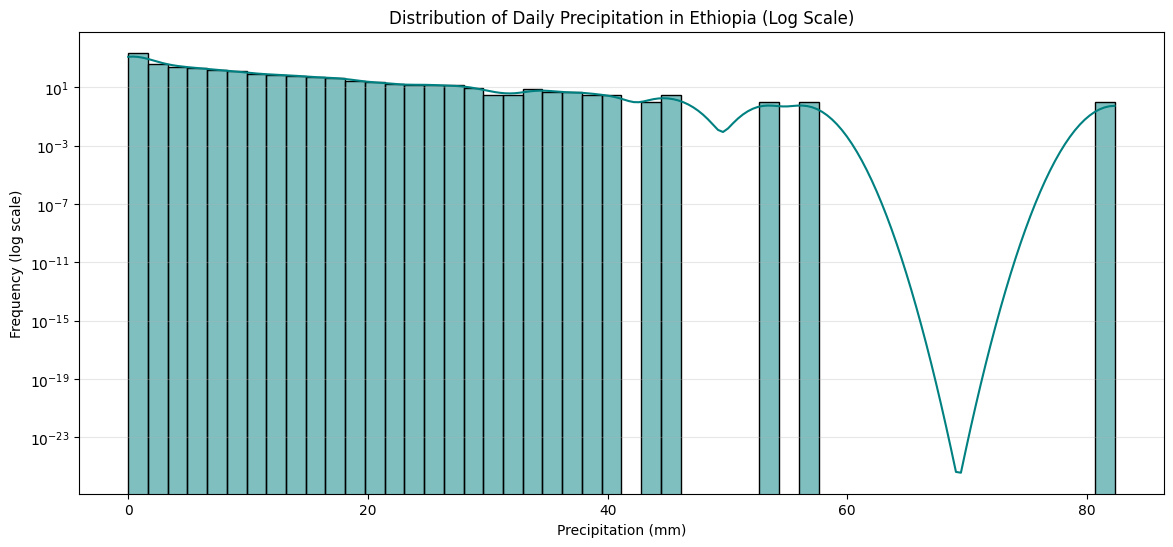

In [67]:
plt.figure(figsize=(14, 6))
sns.histplot(df_eth['PRECTOTCORR'], bins=50, kde=True, color='teal')
plt.yscale('log')
plt.title("Distribution of Daily Precipitation in Ethiopia (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log scale)")
plt.grid(axis='y', alpha=0.3)
plt.show()

**Summary: Precipitation Distribution Analysis**

The data is extremely right-skewed (positively skewed).

**Key Observations:**

-   **Zero-Inflation:** A vast majority of the data is concentrated at zero, reflecting Ethiopia's extended dry seasons where measurable rainfall is absent for long periods.

-   **High-Intensity Events:** The "tail" of the distribution represents rare but critical high-intensity rainfall events. These events account for a large percentage of the total annual water supply despite their low frequency.

**Takeaway:** Because the distribution is non-normal and heavily skewed, the median is a much better measure of a "typical" day than the mean. Using a logarithmic scale is essential to accurately visualize the frequency and variance of actual rainfall events beyond the dominant dry days.

**Action:** Bubble chart: `T2M` vs. `RH2M`, bubble size = `PRECTOTCORR`. 

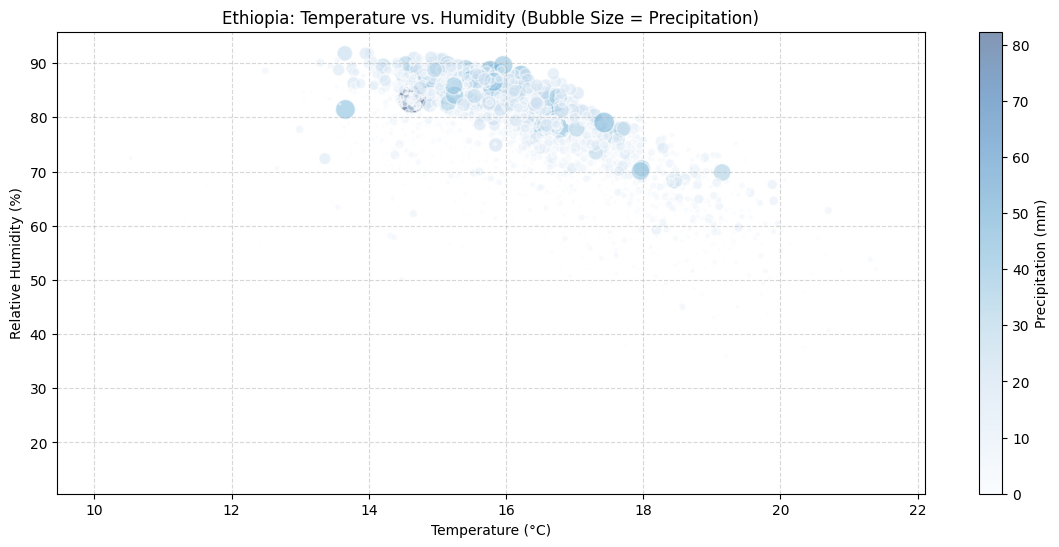

In [69]:
plt.figure(figsize=(14, 6))

scatter = plt.scatter(
    df_eth['T2M'], 
    df_eth['RH2M'], 
    s=df_eth['PRECTOTCORR'] * 5, 
    c=df_eth['PRECTOTCORR'], 
    cmap='Blues', 
    alpha=0.5, 
    edgecolors='w'
)

plt.colorbar(scatter, label='Precipitation (mm)')
plt.title("Ethiopia: Temperature vs. Humidity (Bubble Size = Precipitation)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Summary: T2M vs. RH2M Bubble Chart Analysis**

Large bubbles (representing high rainfall) are strictly concentrated in the High Humidity (>70%) / Moderate Temperature (`18°C – 23°C`) quadrant.

**Key Observations:**

-   **Optimal Convection:** Significant precipitation in Ethiopia is almost exclusively tied to periods of high atmospheric moisture and moderate cooling. This represents the peak convective activity during the Kiremt monsoon.

-   **The Arid Heat Gap:** Data points with high temperatures (`>28°C`) are represented by very small bubbles, confirming that the hottest periods of the year are fundamentally coupled with atmospheric dryness and lack of rainfall.

**Conclusion:** The chart illustrates a clear moisture threshold; rainfall events only "blow up" in size once the air reaches a high degree of saturation. This confirms that humidity is a more direct prerequisite for rain in the highlands than temperature alone.

## Research & Learning References

NASA POWER Documentation: Understand the -999 sentinel value and parameter definitions (T2M vs T2M_MAX)

Pandas Documentation: Mastery of .dt accessors for Julian-to-Gregorian date conversion and ffill logic.

Seaborn Statistical Visualization: Best practices for log-scaled histograms and correlation heatmaps.